In [1]:
from pathlib import Path

import arviz as az
import arviz_plots as azplt
import arviz.preview as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb

from sklearn.model_selection import train_test_split

# Bokeh plotting library and functions. Note, this is probably an overkill but I have used most of these in my other projects.
from bokeh.io import output_notebook, show
from bokeh.models.annotations.labels import Label
from bokeh.layouts import column, row
from bokeh.models import ColumnDataSource, CustomJS, Slider, Whisker, BoxAnnotation, Arrow, OpenHead, Span
from bokeh.plotting import figure, show, output_file, save
from bokeh.models import Legend, LinearAxis, Range1d, ColumnDataSource, LabelSet, HoverTool, DatetimeTickFormatter

%config InlineBackend.figure_format = "retina"

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.27.1


In [2]:
RANDOM_SEED = 5781
np.random.seed(RANDOM_SEED)
az.style.use("arviz-whitegrid")

In [3]:
# Coal mining with BART
try:
    coal = np.loadtxt(Path("..", "data", "coal.csv"))
except FileNotFoundError:
    coal = np.loadtxt(pm.get_data("coal.csv"))

In [4]:
# discretize data
years = int(coal.max() - coal.min())
bins = years // 4
hist, x_edges = np.histogram(coal, bins=bins)
# compute the location of the centers of the discretized data
x_centers = x_edges[:-1] + (x_edges[1] - x_edges[0]) / 2
# xdata needs to be 2D for BART
x_data = x_centers[:, None]
# express data as the rate number of disaster per year
y_data = hist

In [5]:
with pm.Model() as model_coal:
    μ_ = pmb.BART("μ_", X=x_data, Y=np.log(y_data), m=20)
    μ = pm.Deterministic("μ", pm.math.exp(μ_))
    y_pred = pm.Poisson("y_pred", mu=μ, observed=y_data)
    idata_coal = pm.sample(random_seed=RANDOM_SEED)

Multiprocess sampling (4 chains in 4 jobs)
PGBART: [μ_]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 76 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


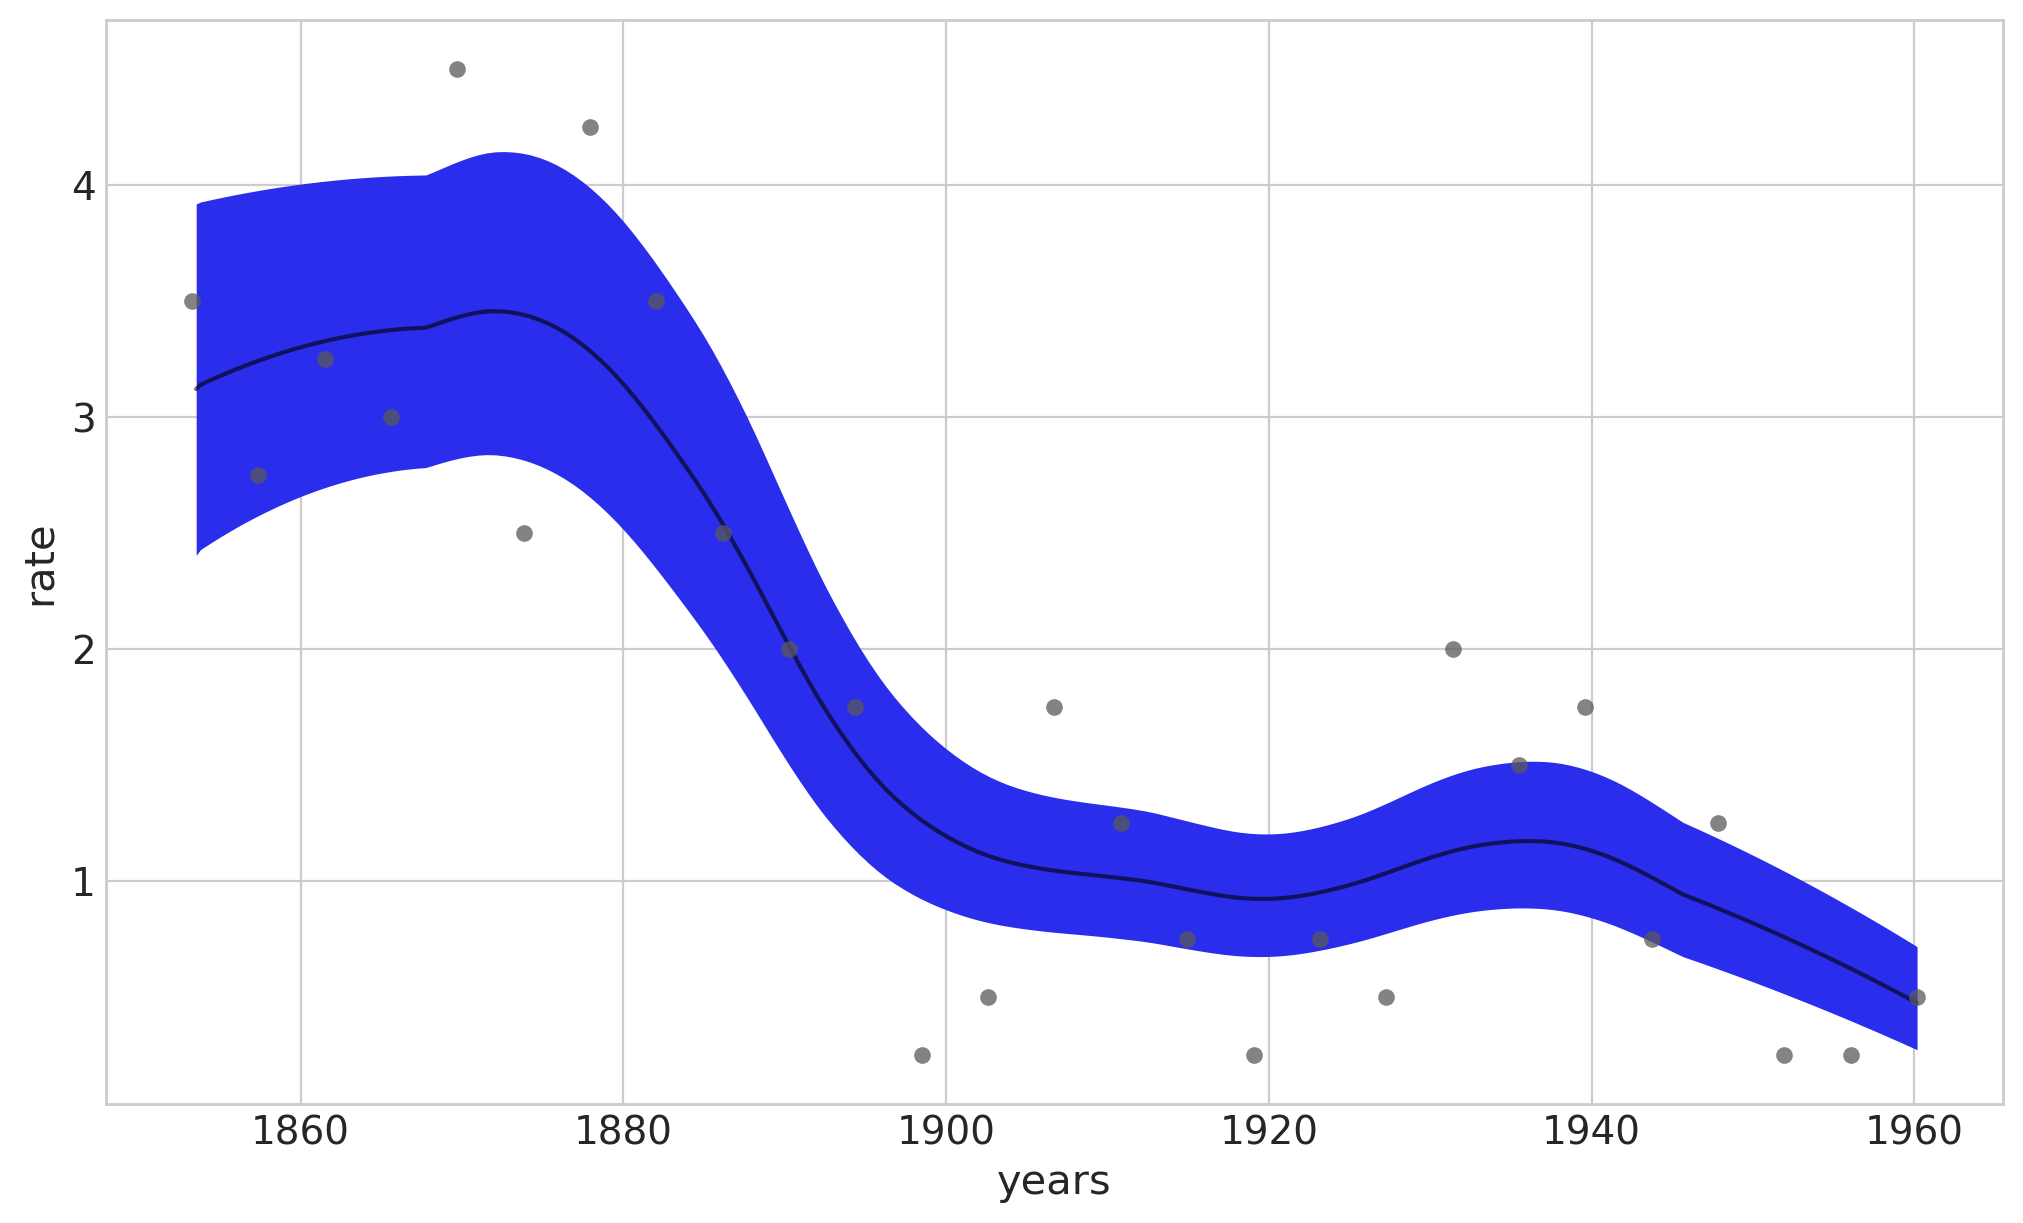

In [6]:
rates = idata_coal.posterior["μ"] / 4

# 1) Build an InferenceData using ArviZ (not arviz_plots)
idata_plot = az.from_dict(
    posterior={"rate": rates},
    observed_data={"rate": y_data / 4},
    constant_data={"years": x_centers},
    dims={"rate": ["x_dim_0"], "years": ["x_dim_0"]},
)

# 2) Convert to DataTree for arviz-plots
dt_plot = az.to_datatree(idata_plot)

azplt.plot_lm(
    dt_plot,
    x="years",
    y="rate",
    y_obs="rate",
    group="posterior",
    visuals={"observed_scatter": {"alpha": 0.75}},
    figure_kwargs={"figsize": (10, 6)},
);

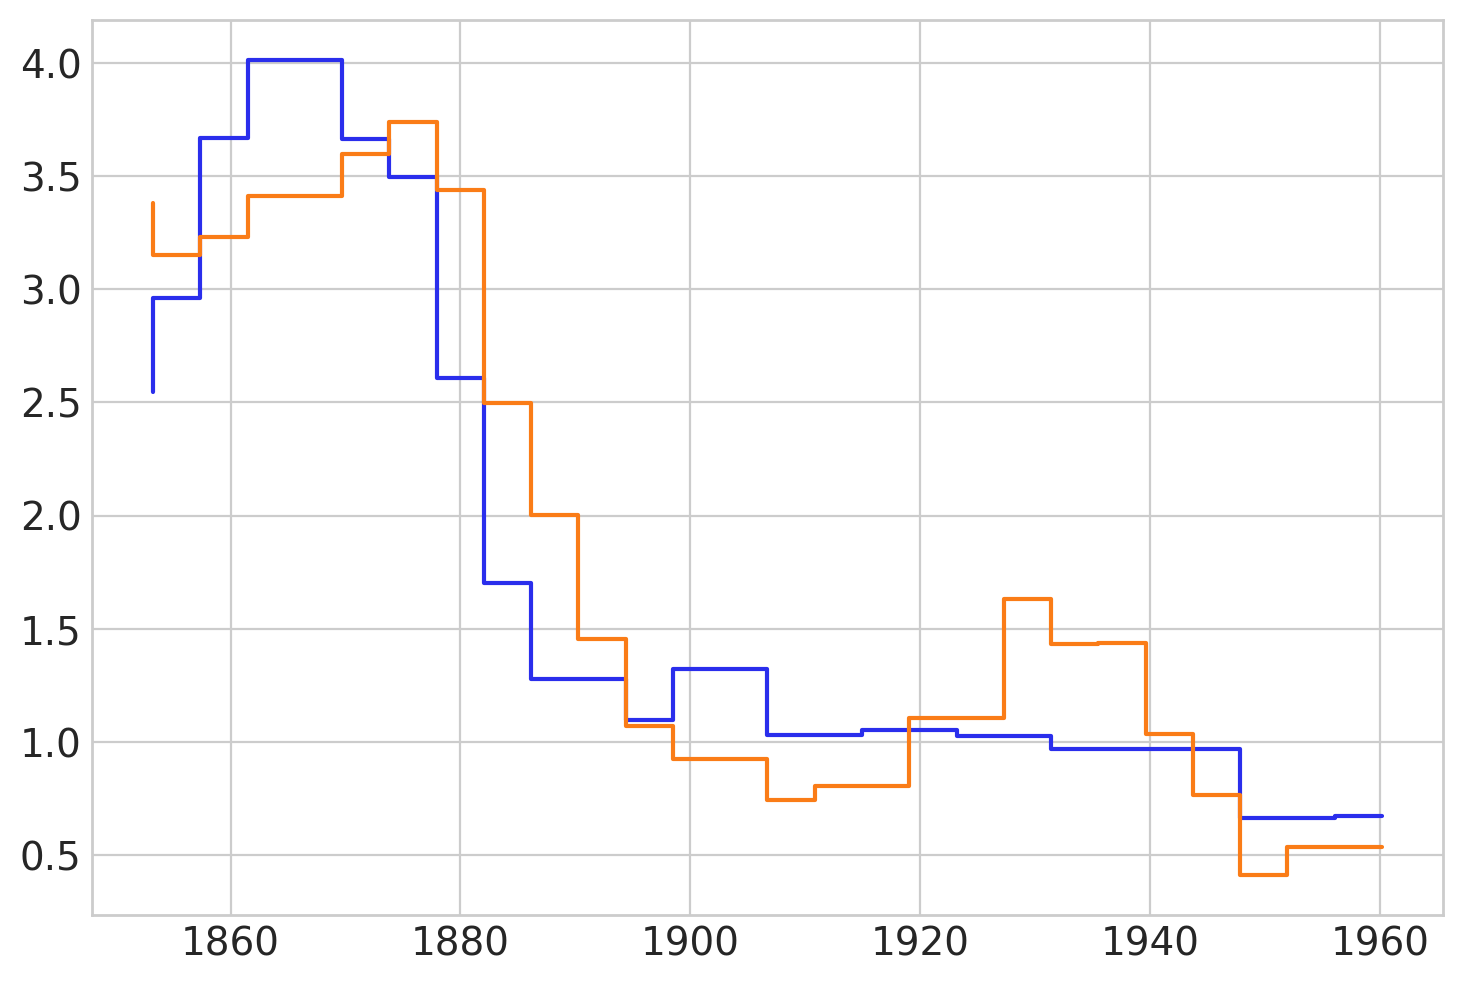

In [7]:
plt.step(x_data, rates.sel(chain=0, draw=[3, 10]).T);

In [11]:
# Biking with BART
try:
    bikes = pd.read_csv(Path("..", "data", "bikes.csv"))
except FileNotFoundError:
    bikes = pd.read_csv(pm.get_data("bikes.csv"))

features = ["hour", "temperature", "humidity", "workingday"]

X = bikes[features]
Y = bikes["count"]

In [12]:
with pm.Model() as model_bikes:
    α = pm.Exponential("α", 1)
    μ = pmb.BART("μ", X, np.log(Y), m=50)
    y = pm.NegativeBinomial("y", mu=pm.math.exp(μ), alpha=α, observed=Y)
    idata_bikes = pm.sample(
        tune=500, draws=2000, compute_convergence_checks=False, random_seed=RANDOM_SEED
    )

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [α]
>PGBART: [μ]


Output()

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 172 seconds.


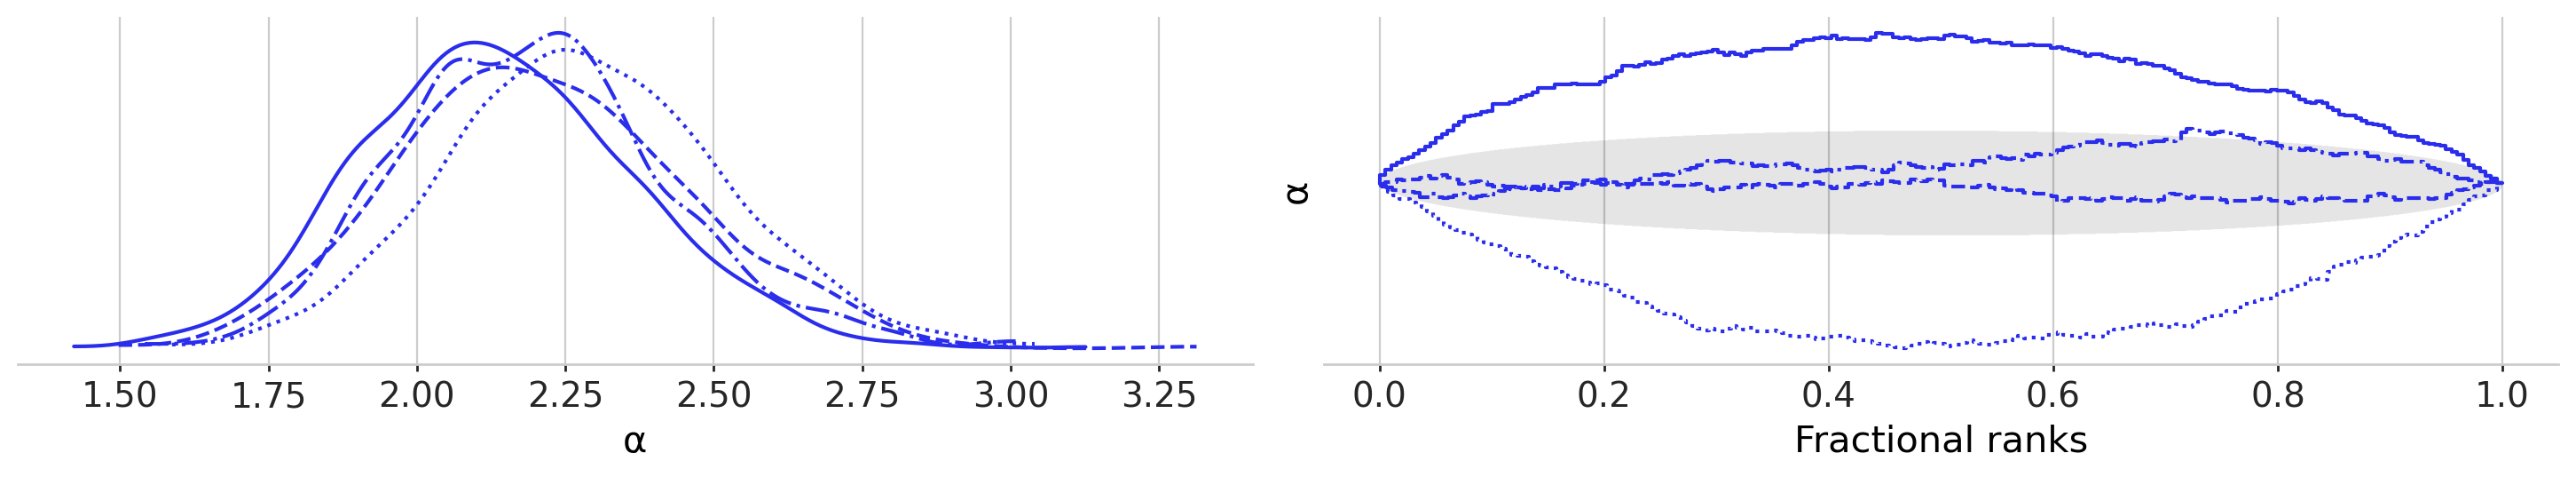

In [14]:
azplt.plot_rank_dist(idata_bikes, var_names=["α"]);

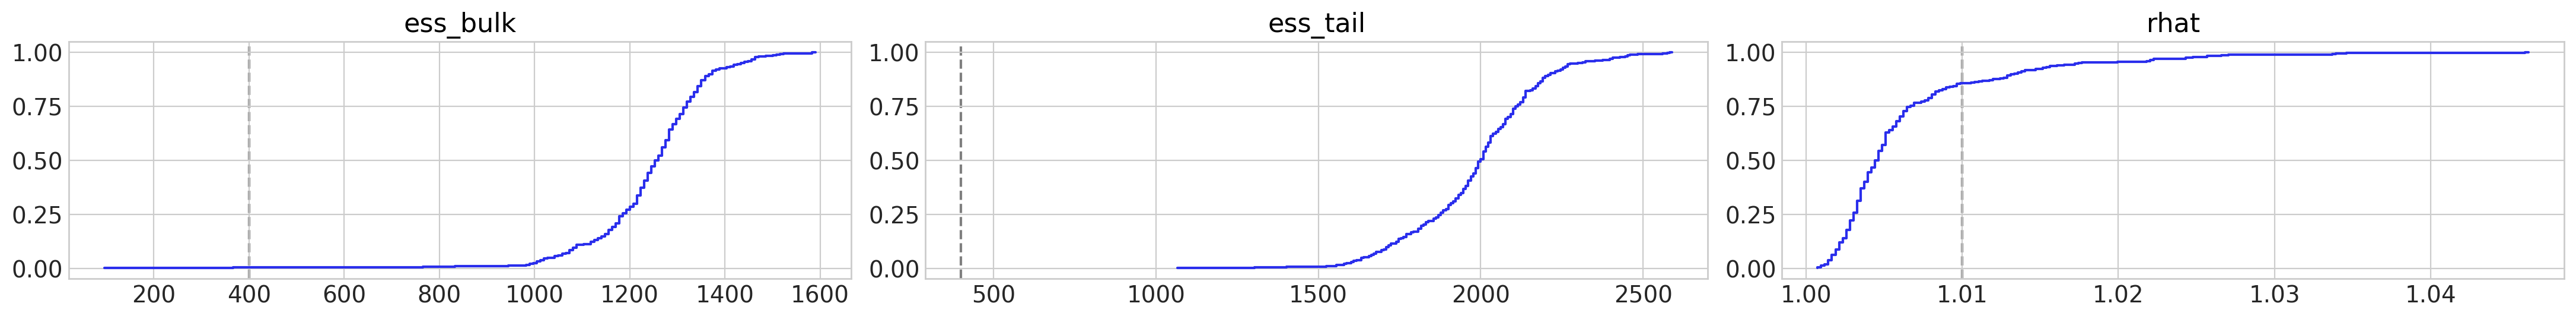

In [15]:
azplt.plot_convergence_dist(idata_bikes, var_names="μ");

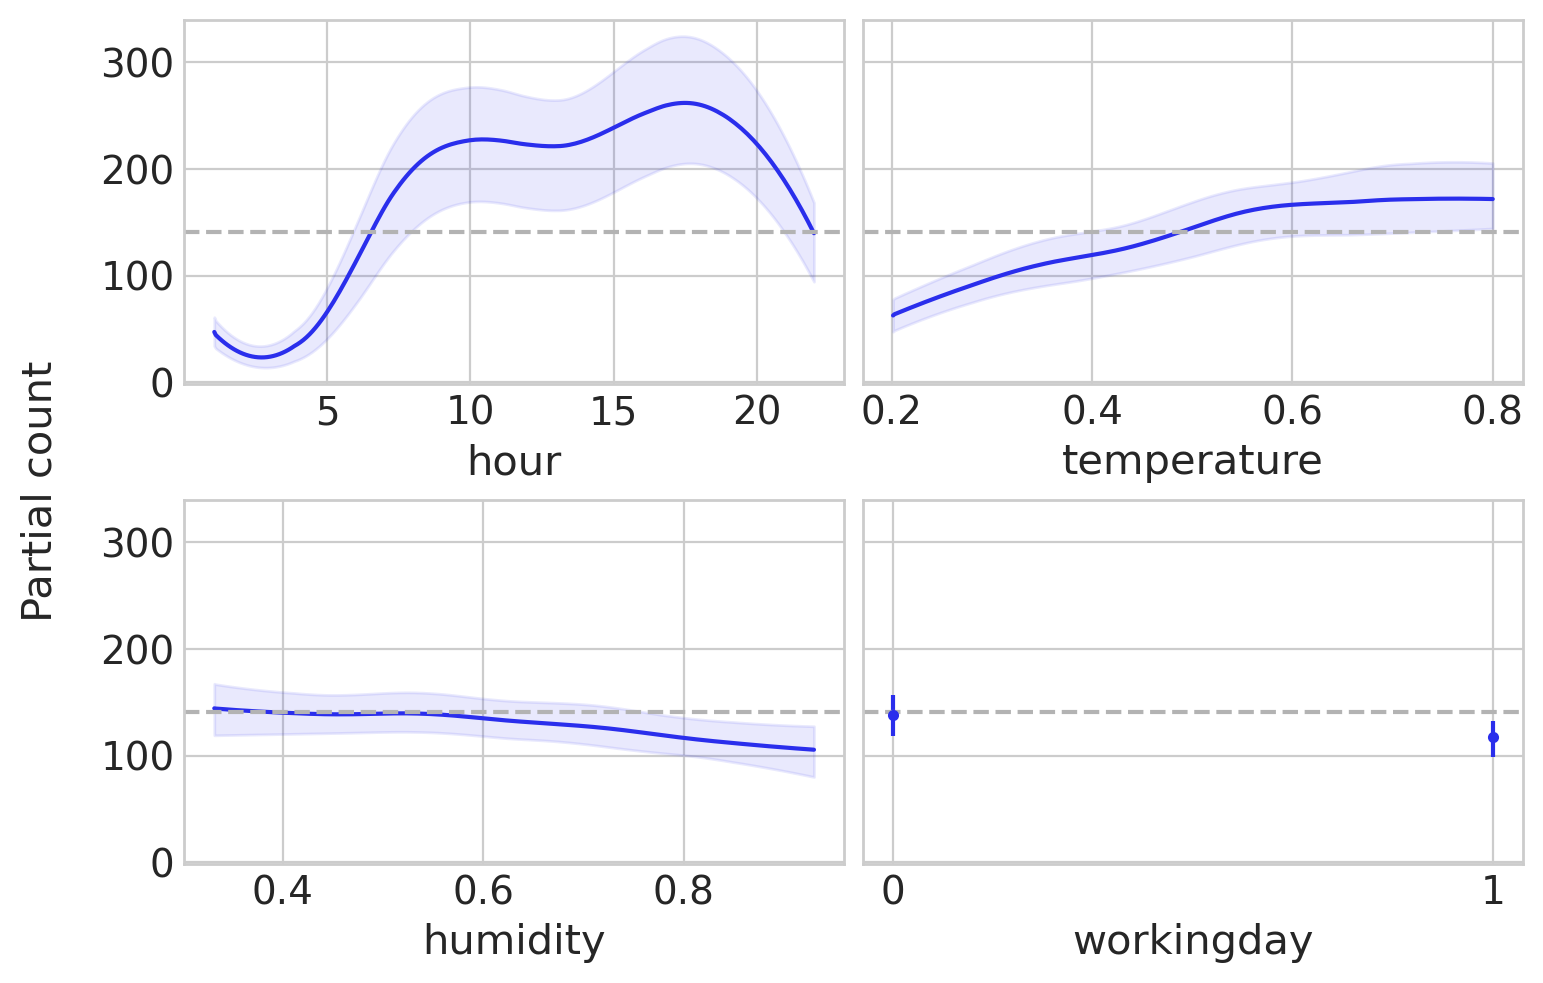

In [16]:
pmb.plot_pdp(μ, X=X, Y=Y, grid=(2, 2), func=np.exp, var_discrete=[3]);

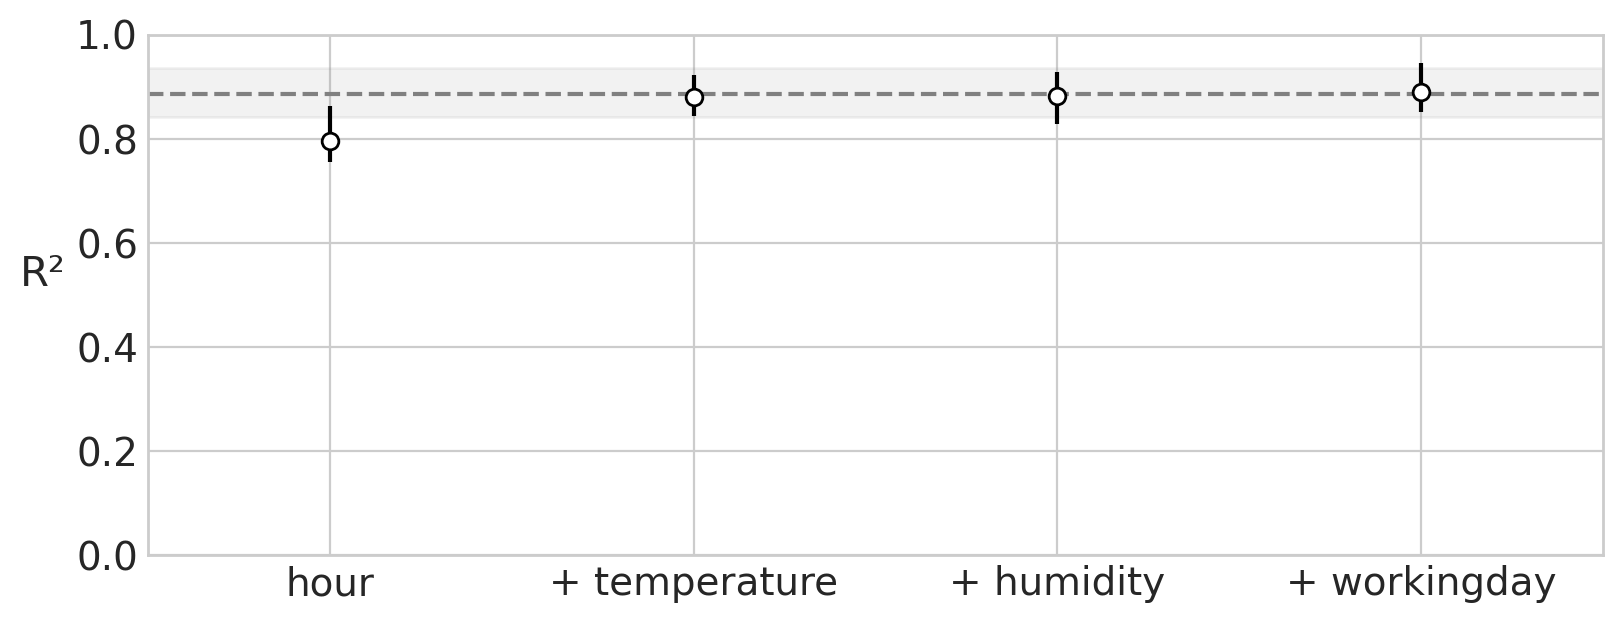

In [17]:
vi_results = pmb.compute_variable_importance(idata_bikes, μ, X)
pmb.plot_variable_importance(vi_results);

In [22]:
vi_results2 = pmb.compute_variable_importance(idata_bikes, μ, X, method="backward")
# method keyword not available for some reason
pmb.plot_variable_importance(vi_results2, method="backward");

TypeError: plot_variable_importance() got an unexpected keyword argument 'method'

In [24]:
print(f"Running on PyMC-BART v{pmb.__version__}")

Running on PyMC-BART v0.11.0


In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_SEED)

In [26]:
with pm.Model() as model_oos_regression:
    X = pm.Data("X", X_train)
    Y = Y_train
    α = pm.Exponential("α", 1)
    μ = pmb.BART("μ", X, np.log(Y))
    y = pm.NegativeBinomial("y", mu=pm.math.exp(μ), alpha=α, observed=Y, shape=μ.shape)
    idata_oos_regression = pm.sample(random_seed=RANDOM_SEED)
    posterior_predictive_oos_regression_train = pm.sample_posterior_predictive(
        trace=idata_oos_regression, random_seed=RANDOM_SEED
    )

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [α]
>PGBART: [μ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 117 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y]


Output()

In [27]:
with model_oos_regression:
    X.set_value(X_test)
    posterior_predictive_oos_regression_test = pm.sample_posterior_predictive(
        trace=idata_oos_regression, random_seed=RANDOM_SEED
    )

Sampling: [y, μ]


Output()

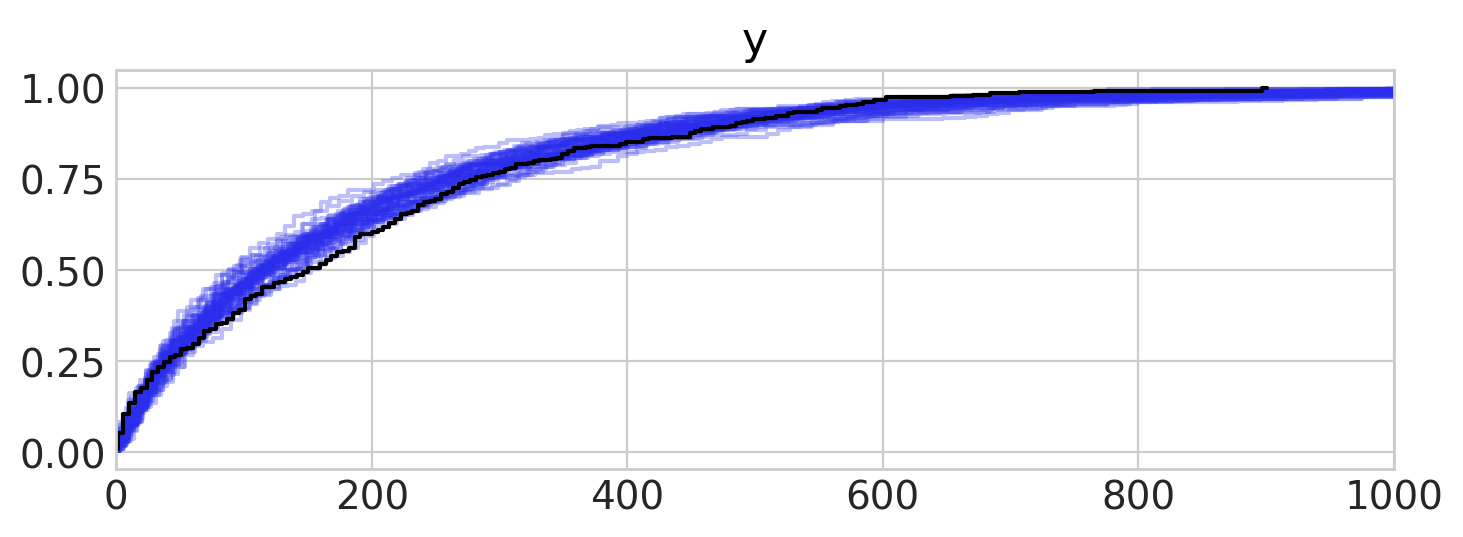

In [29]:
pc = azplt.plot_ppc_dist(posterior_predictive_oos_regression_train, kind="ecdf")
pc.get_viz("plot", "y").set_xlim(0, 1_000);

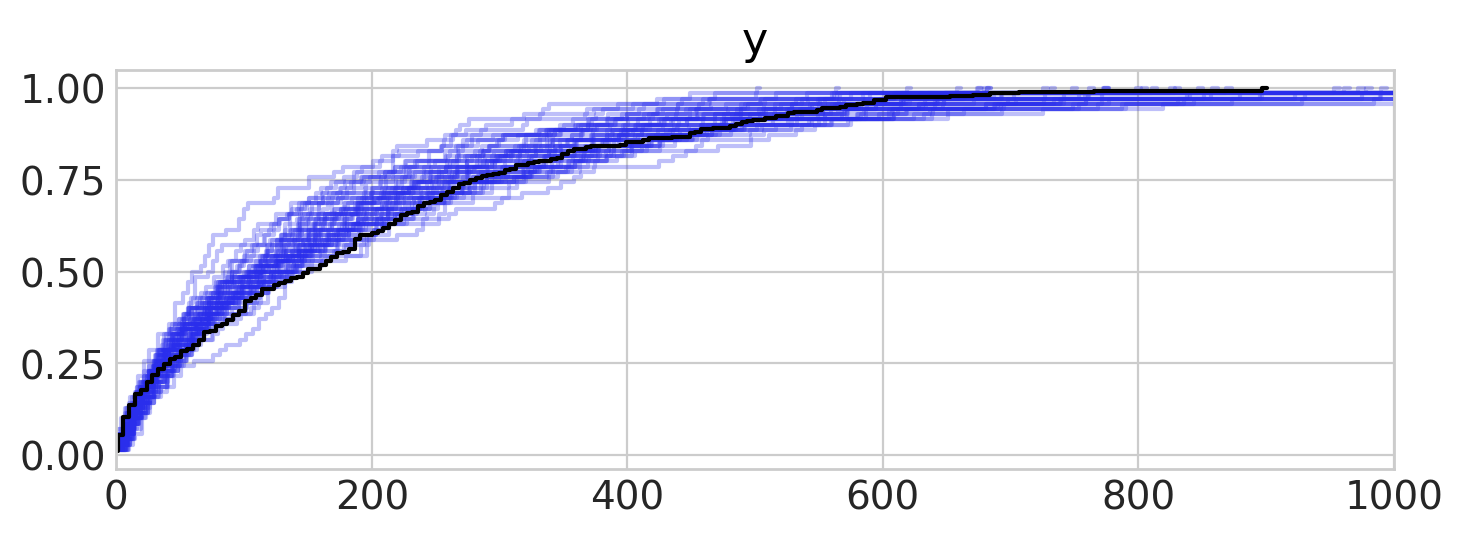

In [30]:
pc = azplt.plot_ppc_dist(posterior_predictive_oos_regression_test, kind="ecdf")
pc.get_viz("plot", "y").set_xlim(0, 1_000);